In [1]:
import os
import sys
import numpy
import pandas
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb, wkt
import pyproj

#import contextily
#import sqlite3
#import pysqlite3 as sqlite3
#import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
# %%time
# dataset = 'powerlines'

# dt_col = 'timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'geom_id'

# intersection_policy = 'original' #'original' #'cut' # 'both'

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 12
# target_level = 8
# max_depth = 4

# # spatial_partition_levels = [4, 6]
# # filter_key_levels = [10, 12, 14]

# # numeric_layers = ['Voltage']
# # timestamp_layers = ['timestamp']
# # categorical_layers = []
# # percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]

# csv_path = '/data/vector/powerlines/Vector_Data_Output.csv'
# df = pandas.read_csv(csv_path)
# df['geometry'] = df['Region'].apply(wkt.loads)
# gdf = geopandas.GeoDataFrame(df, geometry='geometry', crs='4326')
# gdf.index.name = 'geom_id'
# gdf = gdf.reset_index()
# gdf = gdf.rename(columns={'Value': 'Voltage'})
# gdf.loc[gdf['Voltage']==-999999, 'Voltage'] = numpy.nan
# gdf['timestamp'] = gdf['Time'].apply(lambda x: datetime.strptime(x, "%Y-%m-%dT%H:%M:%SZ").replace(tzinfo=pytz.utc))
# gdf = gdf[['geom_id', 'DataSet', 'timestamp', 'Voltage', 'Unit', 'geometry']]
# gdf

In [3]:
%%time
dataset = 'kaggle_wildfire'

dt_col = 'timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'FOD_ID' #'geom_id'

intersection_policy = 'original' #'original' #'cut' # 'both'

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 10
target_level = 10
max_depth = 10

# spatial_partition_levels = [4, 6]
# filter_key_levels = [10, 12, 14]

# numeric_layers = ['Voltage']
# timestamp_layers = ['timestamp']
# categorical_layers = []
# percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]

geoparquet_path = '/data/vector/kaggle_wildfire/gdf_kaggle_wildfire.parquet'

# parquet_path = '/data/vector/kaggle_wildfire/kaggle_wildfire.parquet'
# df = pandas.read_parquet(parquet_path)

# def make_geometry_table(df):
#     # FIRE_SIZE is in acres. 
#     # So let's approximate the geometry by buffereing the point to the area of the FIRE_SIZE (ellipse in WGS84)
#     gdf = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df.LONGITUDE, df.LATITUDE), crs="EPSG:4326")
#     # Switch projection to Pseudo Merkator (almost conformal projection to preserve angles)
#     gdf = gdf.to_crs("EPSG:3857")
#     # Mercator scale factor (for areas use the square)
#     scale_factor = numpy.cos(gdf['LATITUDE'] / 180. * numpy.pi)
#     # Acres to meters
#     gdf['radius'] = numpy.sqrt(gdf['FIRE_SIZE'] * 4046.8564224 / numpy.pi) / scale_factor
#     # Buffer to create a circle
#     gdf['geometry'] = gdf['geometry'].buffer(gdf['radius'])
#     del gdf['radius']
#     # Switch back to WGS84
#     gdf = gdf.to_crs("EPSG:4326")
#     return gdf

# gdf = make_geometry_table(df)
# gdf.to_parquet(geoparquet_path)

gdf = geopandas.read_parquet(geoparquet_path)
gdf.tail(2)

CPU times: total: 14.2 s
Wall time: 14.8 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry
1880463,1831008,300251694,SFO-2015TXLFDX594491,NONFED,ST-NASF,ST/C&L,USTXTXS,Texas A & M Forest Service,TXLFDX,Local Fire Department,...,-94.947366,14.0,MISSING/NOT SPECIFIED,TX,Gregg,183,Gregg,b'\x00\x01\xad\x10\x00\x00\x1cv\x95\xa4\xa1\xb...,2015-12-31 00:00:00+00:00,"POLYGON ((-94.94717 32.43941, -94.94718 32.439..."
1880464,1801139,300213917,W-688210,FED,DOI-WFMI,BIA,USNMZUA,Zuni Agency,NMZUA,Zuni Agency,...,-108.782890,2.0,BIA,NM,None,None,None,b'\x00\x01\xad\x10\x00\x00`\x97\xa8\xde\x1a2[\...,2015-12-31 00:00:00+00:00,"POLYGON ((-108.78267 35.08119, -108.78268 35.0..."


# Qtree index without cutting up any shapes

In [4]:
sys.path.insert(1, os.path.abspath(".."))
import nestedgrid
import mortoncurve
import vectorstore2

In [5]:
from importlib import reload 
reload(mortoncurve)
reload(vectorstore2)
reload(nestedgrid)

<module 'nestedgrid' from 'C:\\Users\\2D1245897\\software\\overviews\\nestedgrid.py'>

In [6]:
grid = nestedgrid.PAIRS()
morton = mortoncurve.Morton(grid)

In [7]:
max_level = 10
target_level = 10
max_depth = 0
target_rows = 50000

In [8]:
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore2.Vectorstore(
    dataset=dataset,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    intersection_policy=intersection_policy,
    verbose=True,
)

# Register data
vs.ingest_geodataframe(gdf)

# Create suggestions for parquet file partitions
vs.create_partitions(target_rows)

len(gdf_unique)     1880465
Time for initialization (A) in seconds 16.616
gdf_head   1880465
gdf_target 1869437
gdf_tree   11028
Time for recursive BFS (B) in seconds 1.519
Time for finalizing gdf_concat (C) in seconds 6.378
Time for finalizing gdf_target (D) in seconds 6.715
Time for creating df_idx (E) in seconds 0.03
Number of partitions suggested 50


In [9]:
vs.gdf_partition['partition'].unique()

array(['0q00233300', '0q00233302', '0q00323013', '0q00323020',
       '0q00323022', '0q00323103', '0q00323112', '0q00323121',
       '0q00323123', '0q00323130', '0q00323131', '0q00323132',
       '0q00323133', '0q00332022', '0q00332230', '0q0023312', '0q0023313',
       '0q0023321', '0q0023323', '0q0032202', '0q0032211', '0q0032213',
       '0q0032221', '0q0032300', '0q0032302', '0q0032303', '0q0032311',
       '0q0032312', '0q0032320', '0q0032331', '0q0033220', '0q0033222',
       '0q0201110', '0q0201111', '0q0210100', '0q002333', '0q003222',
       '0q003223', '0q003232', '0q003233', '0q003322', '0q021001',
       '0q00322', '0q00323', '0q02011', '0q02101', '0q0032', '0q0033',
       '0q021', '0q'], dtype=object)

In [12]:
vs.parquet_directory

'data/vector/vectorstore/kaggle_wildfire/grid=PAIRS(4326)'

In [13]:
vs._decode_filepath('data/vector/vectorstore/kaggle_wildfire/grid=PAIRS(4326)/0q00233300.parquet')

({}, '0q00233300')

In [14]:
vs._filepath({}, '0q00233300')

'data/vector/vectorstore/kaggle_wildfire/grid=PAIRS(4326)/0q00233300.parquet'

In [15]:
vs._select_partition({}, '0q00233300').tail(2)

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry,q_key
29942,1872020,300308379,SFO-2015CACDFFKU019727,NONFED,ST-NASF,ST/C&L,USCAFKU,Fresno-Kings Unit,CAFKU,CDF - Fresno-Kings Unit,...,14.0,MISSING/NOT SPECIFIED,CA,FRESNO,019,Fresno,b'\x00\x01\xad\x10\x00\x00\x90\x96\xca\xdb\x11...,2015-12-18 00:00:00+00:00,"POLYGON ((-120.56348 36.93537, -120.56348 36.9...",0q0023330021
29943,1871978,300308335,SFO-2015CACDFFKU020374,NONFED,ST-NASF,ST/C&L,USCAFKU,Fresno-Kings Unit,CAFKU,CDF - Fresno-Kings Unit,...,14.0,MISSING/NOT SPECIFIED,CA,FRESNO,019,Fresno,b'\x00\x01\xad\x10\x00\x00\xc4\xff\x1dQ\xa1\xe...,2015-12-31 00:00:00+00:00,"POLYGON ((-119.55659 36.53661, -119.55659 36.5...",0q0023330013


In [16]:
#vs._to_parquet({}, '0q00233300')

In [17]:
%%time
vs.to_parquet()

CPU times: total: 48 s
Wall time: 1min 8s


In [19]:
%%time
gdf_saved = geopandas.read_parquet(vs.parquet_directory)
gdf_saved.tail(2)

CPU times: total: 14.8 s
Wall time: 16.7 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry,q_key
1880463,1829499,300249295,SFO-2015MNDNR-2015-312-182,NONFED,ST-NASF,ST/C&L,USMNMNS,Minnesota Department of Natural Resources,MNDNR,Minnesota Department of Natural Resources,...,8.0,PRIVATE,MN,Morrison,097,Morrison,b'\x00\x01\xad\x10\x00\x00\xb4O\x9e\xe4T\x95W\...,2015-11-28 00:00:00+00:00,"POLYGON ((-94.33316 45.97722, -94.33316 45.977...",0q0210100033
1880464,1829508,300249305,SFO-2015MNDNR-2015-312-184,NONFED,ST-NASF,ST/C&L,USMNMNS,Minnesota Department of Natural Resources,MNDNR,Minnesota Department of Natural Resources,...,8.0,PRIVATE,MN,Benton,009,Benton,b'\x00\x01\xad\x10\x00\x00\xc0Z\x10%\xb5wW\xc0...,2015-11-30 00:00:00+00:00,"POLYGON ((-93.86643 45.79656, -93.86645 45.796...",0q0210100122


In [24]:
filepath = os.path.join(vs.parquet_directory, '0q00233300.parquet').replace('\\', '/')
gdf_part = geopandas.read_parquet(filepath)
gdf_part.tail(2)

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry,q_key
29942,1872020,300308379,SFO-2015CACDFFKU019727,NONFED,ST-NASF,ST/C&L,USCAFKU,Fresno-Kings Unit,CAFKU,CDF - Fresno-Kings Unit,...,14.0,MISSING/NOT SPECIFIED,CA,FRESNO,019,Fresno,b'\x00\x01\xad\x10\x00\x00\x90\x96\xca\xdb\x11...,2015-12-18 00:00:00+00:00,"POLYGON ((-120.56348 36.93537, -120.56348 36.9...",0q0023330021
29943,1871978,300308335,SFO-2015CACDFFKU020374,NONFED,ST-NASF,ST/C&L,USCAFKU,Fresno-Kings Unit,CAFKU,CDF - Fresno-Kings Unit,...,14.0,MISSING/NOT SPECIFIED,CA,FRESNO,019,Fresno,b'\x00\x01\xad\x10\x00\x00\xc4\xff\x1dQ\xa1\xe...,2015-12-31 00:00:00+00:00,"POLYGON ((-119.55659 36.53661, -119.55659 36.5...",0q0023330013


<Axes: >

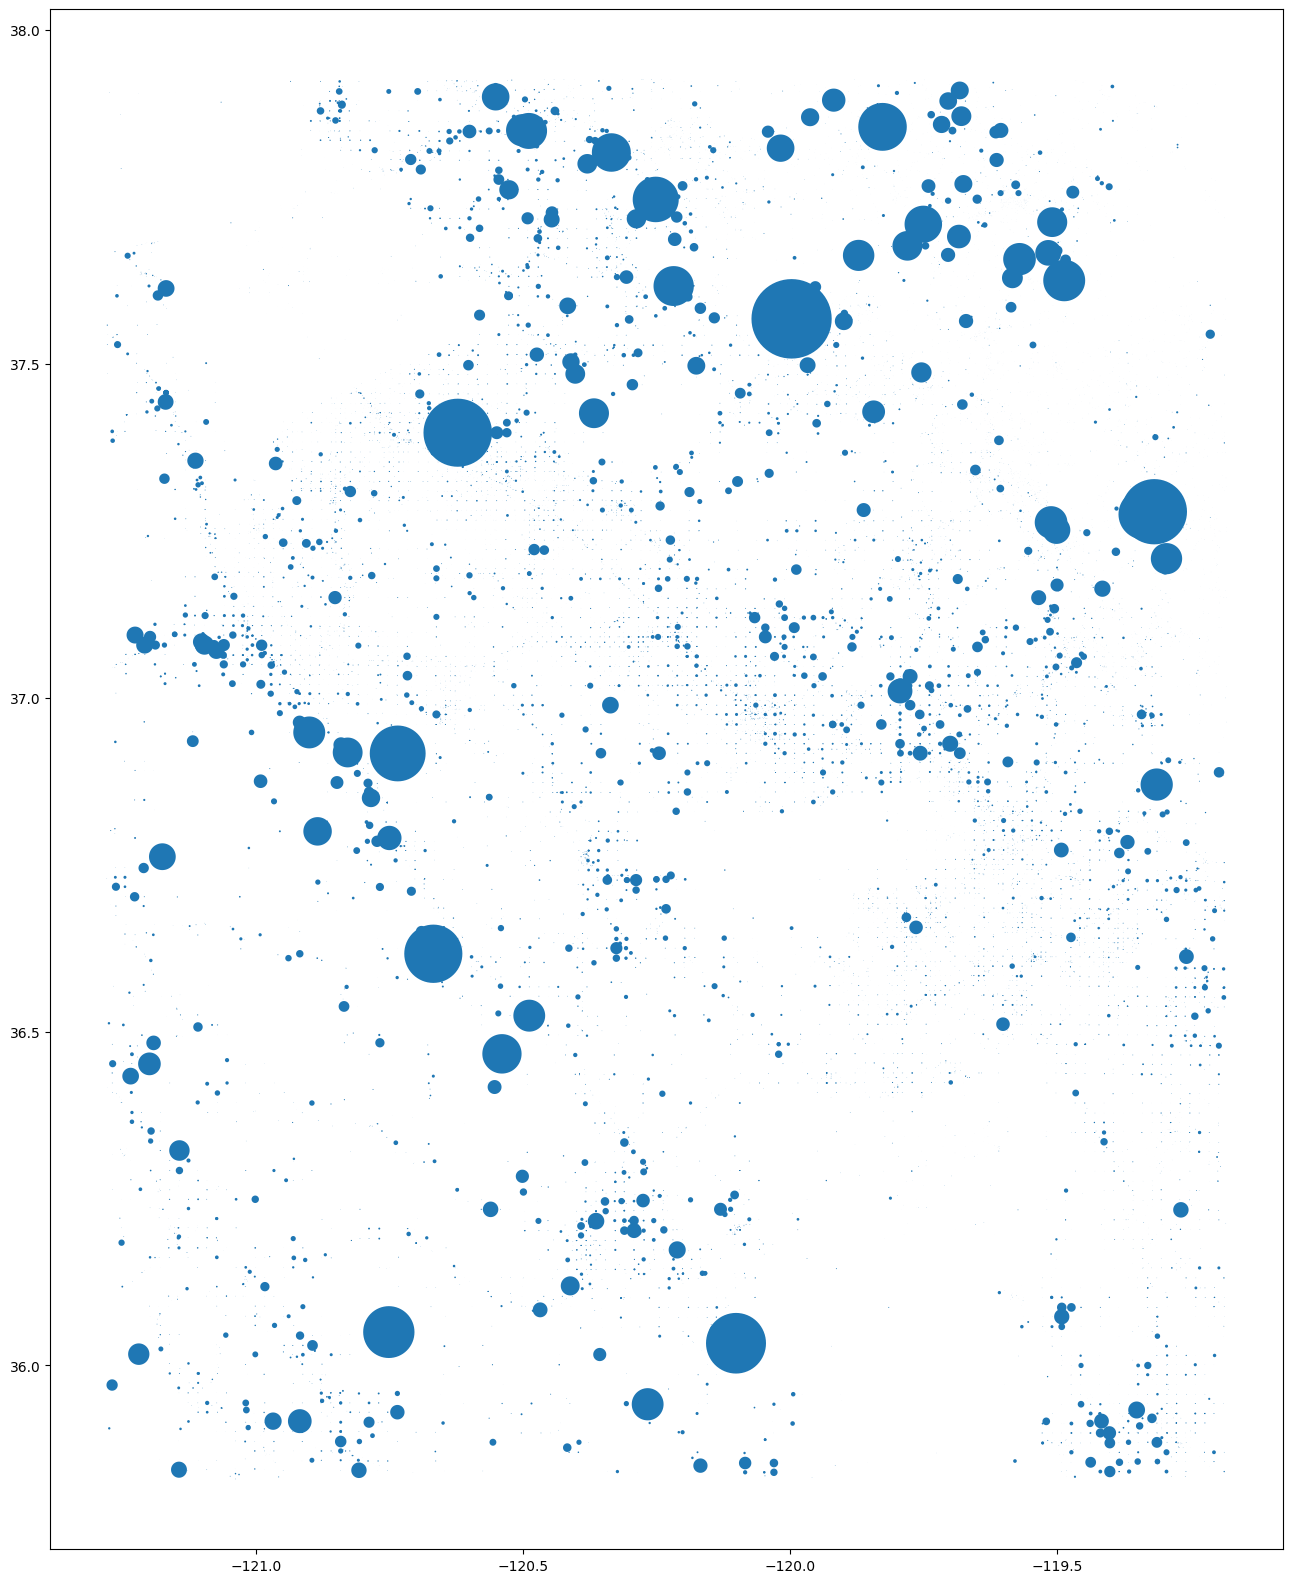

In [26]:
gdf_part.plot(figsize=(20,20))

In [ ]:
# Add the partition column to df_idx
try:
    del vs.df_idx['partition']
except:
    pass

vs.df_idx = pandas.merge(
    vs.df_idx,
    vs.gdf_partition[['head', 'partition']],
    on='head',
)

vs.df_idx

In [ ]:
spatial_partition = '0q00233300'
temporal_partitions = {}
gdf_part = pandas.merge(
    vs.gdf,
    vs.df_idx[vs.df_idx['partition']==spatial_partition][[id_col, 'head']],
    on=id_col,
).rename(columns={'head': 'q_key'})
gdf_part.T

In [ ]:
vs.df_idx

In [ ]:
# %%time
# # Create dictionaries containing entire bfs quadtrees (indexed by level) for every geometry id
# # List of q_keys by level and geometry ID
# df_idx = vs.gdf_concat[[id_col, 'level', 'q_key']].groupby([id_col, 'level'])['q_key'].apply(list).reset_index(level=0)
# # Dictionaries containing entire bfs quadtrees (indexed by level) for every geometry id
# df_idx = df_idx.groupby(id_col).apply(lambda x: x['q_key'].to_dict()).rename('qtree').reset_index()
# df_idx = pandas.merge(
#     vs.gdf_head.rename(columns={'q_key': 'head'}),
#     df_idx,
#     on=id_col,
# )
# df_idx

In [ ]:
# # Partition the table
# target_rows = 10000
# df_partition = pandas.DataFrame()
# df_count = df_idx.groupby('head')[id_col].count().rename('head_count').reset_index()
# # Initialize partition key with head
# df_count['partition'] = df_count['head']
# df_count['count'] = df_count['head_count']

# # Breadth First Search starting at highest resolution level
# df_count['level'] = df_count['partition'].apply(lambda x: len(x)-2)
# level = df_count['level'].max()
# n_rows = target_rows/2
# while level>=0:
#     # Check if any of the counts at specific level have reached target_rows
#     df_level = df_count[df_count['level']==level]
#     df_count = df_count[df_count['level']!=level]
    
#     # Separate the keys with number of rows above target_rows
#     if level==0:
#         n_rows = 0
#     df_partition = pandas.concat([
#         df_partition,
#         df_level[df_level['count']>=n_rows].reset_index(drop=True),
#     ])
#     df_level = df_level[df_level['count']<n_rows].reset_index(drop=True)
    
#     # Get the parent keys and decrease the level for the next iteration
#     df_level['partition'] = df_level['partition'].apply(lambda x: x[:-1])
#     level-=1
#     df_level['level'] = level
    
#     df_count = pandas.concat([df_count, df_level])
#     df_count['count'] = df_count.groupby('partition')['head_count'].transform('sum')
    
# df_partition = df_partition[['head', 'partition', 'level', 'count']].sort_values(by='head').reset_index(drop=True)
# df_partition

In [ ]:
df = vs.gdf_partition[['partition', 'count']].drop_duplicates().sort_values(by='partition').reset_index(drop=True)
df.plot()
df.tail()

In [ ]:
vs.gdf_partition.plot(color='none')

In [ ]:
# Prune the trees. Two-fold strategy:
# (1) Prune if two levels down, we have more than 4 grand-children.
# (2) Prune if one level down, we have 3 or more leaf nodes.

In [ ]:
# %%time
# # (1) Prune if two levels down, we have more than 4 grand-children.
# df = gdf_concat.copy()
# df['prune_key'] = df['q_key'].apply(lambda x: x[:-2]) # Grandparent
# df['count'] = df[[id_col, 'prune_key', 'q_key']].groupby([id_col, 'prune_key']).transform('count')
# df_prune_nodes = df[df['count']>4][[id_col, 'prune_key']].drop_duplicates().reset_index(drop=True)
# df_prune_nodes['level'] = df_prune_nodes['prune_key'].apply(lambda x: len(x)-2)

# cols = gdf_concat.columns
# for level in reversed(sorted(set(df_prune_nodes['level']))):
#     df1 = gdf_concat[gdf_concat['level']>level]
#     df1['prune_key'] = df1['q_key'].apply(lambda x: x[:level+2])
#     df1 = pandas.concat([df1, gdf_concat[gdf_concat['level']<=level]])
#     # Drop rows based on a "negative" merge
#     gdf_concat = pandas.merge(
#         df1,
#         df_prune_nodes[df_prune_nodes['level']==level][[id_col, 'prune_key']],
#         on=[id_col, 'prune_key'],
#         how="outer",
#         indicator=True
#     )
#     gdf_concat = gdf_concat[gdf_concat['_merge']=='left_only'].reset_index(drop=True)[cols]
# gdf_concat

In [ ]:
id = 48 #88553
ax = vs.gdf_concat[vs.gdf_concat[id_col]==id].plot(color='none')
gdf[gdf[id_col]==id].plot(ax=ax, color='orange')

In [ ]:
id = 48 #88553
ax = vs.gdf_target[vs.gdf_target[id_col]==id].plot(color='none')
gdf[gdf[id_col]==id].plot(ax=ax, color='orange')

In [ ]:
plt.hist(vs.gdf_target.groupby(id_col).count()['geometry'], log=True)
plt.xlabel('Number of children per geometry')
plt.ylabel('Count')
plt.title('Histogram df_target')
plt.show()

In [ ]:
plt.hist(vs.gdf_concat.groupby(id_col).count()['geometry'], log=True)
plt.xlabel('Number of children per geometry')
plt.ylabel('Count')
plt.title('Histogram df_concat')
plt.show()

In [ ]:
# poly = shapely.box(-180, -90, 0, 90)
# gdf1 = vs.gdf_concat[gdf_concat.intersects(poly)]
# gdf1['color'] = numpy.round(numpy.array(gdf1.index/len(gdf1)*19)).astype(int)
# gdf1.plot(gdf1['color'], cmap='tab20', figsize=(20,20))

In [ ]:
poly = shapely.box(-100, 30, -90, 40)
poly = shapely.box(-95, 35, -90, 40)
poly = shapely.box(-98, 38, -96, 40)
#gdf1 = vs.gdf_concat[vs.gdf_concat.intersects(poly)]
gdf1 = vs.gdf_target[vs.gdf_target.intersects(poly)]
gdf2 = gdf[gdf.intersects(poly)]

In [ ]:
gdf1

In [ ]:
ax = gdf1.drop_duplicates(subset='q_key').plot(color='none', figsize=(20,20))
gdf2.plot(ax=ax, color='orange')
plt.show()

In [ ]:
gdf_large = vs.gdf_target[vs.gdf_target.groupby(id_col).transform('count')['geometry']==vs.gdf_target.groupby(id_col).transform('count')['geometry'].max()].reset_index(drop=True)
# gdf_large = vs.gdf_concat[vs.gdf_concat.groupby(id_col).transform('count')['geometry']==vs.gdf_concat.groupby(id_col).transform('count')['geometry'].max()].reset_index(drop=True)
gdf_large.tail(2)

In [ ]:
gdf[gdf[id_col].isin(gdf_large[id_col].unique())]

In [ ]:
gdf_large[id_col].unique()

In [ ]:
ax = gdf_large.plot(color='none')
gdf[gdf[id_col].isin(gdf_large[id_col].unique())].plot(ax=ax, color='orange')

In [ ]:
poly = shapely.box(-180, -90, 0, 90)
poly = shapely.box(-130, 20, -60, 70)
gdf1 = vs.gdf_target[vs.gdf_target.intersects(poly)].reset_index(drop=True)
gdf1['color'] = numpy.round(numpy.array(gdf1.index/len(gdf1)*19)).astype(int)
gdf1.plot(gdf1['color'], cmap='tab20', alpha=0.1, figsize=(20,20))

In [ ]:
stop

In [ ]:
%%time
def _loop(gdf_tree, df_concat):
    """Calculate the next level of children keys."""
    # Generate 4 child columns representing the 4 quadrants we need to check for intersections
    df_children = pandas.DataFrame(
        gdf_tree['q_key'].apply(lambda x: _children(x)).to_list(),
        columns=children
    )
    
    # Create the children bounding boxes
    for child in children:
        try:
            df_children[child + '_bounds'] = morton.base4_to_box(df_children[child])
        except OverflowError as e:
            print(e)
            print(child, 'failed to use numpy due to large integers. Switching to pandas')
            df_children[child + '_bounds'] = df_children[child].apply(morton.base4_to_box)
    
    # Check for intersection of original geometry with children
    for child in children:
        mask = gdf_tree.intersects(
            geopandas.GeoSeries(df_children[child + '_bounds']).set_crs(vs.morton.grid.crs)
        )
        df_children[child] = df_children[child].where(mask)
    df_children = pandas.concat([gdf_tree[['geom_id', 'q_key']], df_children[children]], axis=1)
    print('debug')
    
    # Stack the child q_keys
    df_children = df_children.set_index(['geom_id', 'q_key']).stack().reset_index(level=2, drop=True).rename('child_key').reset_index()
    
    # Remove leaf nodes
    
    # Remove the keys that have reached the target level
    df_concat = pandas.concat([
        df_concat,
        df_children[df_children['child_key'].apply(len)>=target_level+2].reset_index(drop=True),
    ]).reset_index(drop=True)

    # Update the keys we need to work on
    gdf_tree = pandas.merge(
        gdf_tree[['geom_id', 'geometry']],
        df_children[df_children['child_key'].apply(len)<target_level+2].reset_index(drop=True),
        on='geom_id',
    )

    return gdf_tree, df_concat, df_children

depth = 0
while depth < max_depth:
    depth+=1
    print('depth', depth)
    gdf_tree, df_concat, df_children = _loop(gdf_tree, df_concat)

In [ ]:
mask = (df_children.groupby(['geom_id', 'q_key']).transform('count')==4)['child_key']
df_children[mask]

In [ ]:
df_children.groupby('geom_id').count().max()

In [ ]:
gdf_tree

In [ ]:
q_key = vs.gdf_unique.loc[0, 'q_key']
q_key

In [ ]:
keys, levels = morton.decode(vs.gdf_unique['q_key'])
keys

In [ ]:
import qtree
head = qtree.Node(morton, levels[0], keys[0])

In [ ]:
vars(head)

In [ ]:
%%time
# Geometry bounds
minx = numpy.array(gdf.bounds.minx)
miny = numpy.array(gdf.bounds.miny)
maxx = numpy.array(gdf.bounds.maxx)
maxy = numpy.array(gdf.bounds.maxy)

level = max_level
while level>=0:
    # Calculate the sw and ne corner pixel keys based on level
    sw_keys = morton.get_key(miny, minx, level)
    ne_keys = morton.get_key(maxy, maxx, level)

    # If the keys are the same, we have a good key. Otherwise mask (with -1)
    keys = sw_keys.copy()
    keys[sw_keys!=ne_keys] = -1 # -1 interpreted as nan
    levels = sw_keys * 0 + level
    levels[sw_keys!=ne_keys] = -1 # -1 interpreted as nan

    # Fill masked values by the next lower level if possible
    if level==max_level:
        agg_keys = keys
        agg_levels = levels
    else:
        agg_keys[agg_keys==-1] = keys[agg_keys==-1]
        agg_levels[agg_levels==-1] = levels[agg_levels==-1]
    
    level-=1

gdf['q_key'] = morton.encode(agg_keys, agg_levels)

try:
    # The numpy method is much faster if integers are small enough
    gdf['idx_bounds'] = morton.base4_to_box(gdf['q_key'])
except OverflowError as e:
    print(e)
    print('Failed to use numpy due to large integers. Switching to pandas')
    gdf['idx_bounds'] = gdf['q_key'].apply(lambda x: morton.base4_to_box(x))
    
gdf.tail(2)

In [ ]:
geopandas.GeoDataFrame(gdf, geometry='idx_bounds').plot(color='orange', edgecolor='k', alpha=0.01, lw=.5)

In [ ]:
gdf['q_key'].apply(lambda x: x[:10])

In [ ]:
poly = shapely.box(-180, -90, 0, 90)
gdf1 = gdf_concat[gdf_concat.intersects(poly)]
gdf1['color'] = numpy.round(numpy.array(gdf1.index/len(gdf1)*19)).astype(int)
gdf1.plot(gdf1['color'], cmap='tab20', figsize=(20,20))

In [ ]:
import nestedgrid
import mortoncurve
import qtree

In [ ]:
max_level = 8
target_level = 8
max_parts = 1

In [ ]:
grid = nestedgrid.PAIRS()
morton = mortoncurve.Morton(grid)

In [ ]:
# Breadth First Search to generate the Qtree index for all the bounding boxes.
qt = qtree.QTree(shapely.box(3.1, 3.9, 4.1, 4.9), max_level, head_only=True)
qt.walker(max_level, 3)

In [ ]:
qt.head.encode()

In [ ]:
%%time
max_level=10
gdf.loc[0:10000, 'geometry'].apply(lambda x: qtree.QTree(x, max_level, head_only=True).head.encode())

In [ ]:
%%time
max_level=20
gdf.loc[0:10000, 'bounds'].apply(lambda x: qtree.QTree(x, max_level, head_only=True).head.encode())

In [ ]:
def myfunc(x):
    return qtree.QTree(x, max_level, head_only=True).head.encode()

In [ ]:
%%time
myfunc(gdf.loc[10000, 'geometry'])

In [ ]:
vfunc = numpy.vectorize(myfunc, doc='Vectorized `myfunc`')

In [ ]:
%%time
vfunc(gdf.loc[0:10000, 'geometry'])

In [ ]:
gdf_bounds = gdf.copy()
gdf_bounds['geometry'] = gdf_bounds['bounds']
del gdf_bounds['bounds']

gdf_right = gdf_bounds.copy()
gdf_right.tail(2)

In [ ]:
%%time
# Breadth First Search to generate the "Head" Qtree index (no cuts allowed).
gdf_bounds = gdf.copy()
gdf_bounds['geometry'] = gdf_bounds['bounds']
del gdf_bounds['bounds']

gdf_right = gdf_bounds.copy()
gdf_right = gdf.copy()

gdf_contains = geopandas.GeoDataFrame()
gdf_idx = geopandas.GeoDataFrame()
level = -1
while (level<max_level) and (len(gdf_right)>0):
    level+=1
    print(level)
    # Create gdf_left, containing the desired grid at specified level
    qt = qtree.QTree(morton.valid_range, level)
    keys = qt.gridded(level)
    gdf_left = geopandas.GeoDataFrame({
        'q_key': morton.encode(keys, level), 
        'geometry': morton.key_to_box(qt.gridded(level), level)
    }, crs=grid.crs)

    # Containment operation to assign the correct keys of specified level
    gdf_contains_saved = gdf_contains.copy()
    gdf_contains = gdf_left.sjoin(gdf_right[['geom_id', 'geometry']], predicate='contains')

    # Geometries not fully contained in any of the qtree boxes of given level
    cut_lst = sorted(set(gdf_right['geom_id']) - set(gdf_contains['geom_id']))
    if len(gdf_contains_saved)>0:
        gdf_idx = pandas.concat([gdf_idx, gdf_contains_saved[gdf_contains_saved['geom_id'].isin(cut_lst)][['q_key', 'geom_id']]])
    gdf_right = gdf_right[~gdf_right['geom_id'].isin(cut_lst)]

remaining_lst = sorted(set(gdf_right['geom_id']))
gdf_idx = pandas.concat([gdf_idx, gdf_contains[gdf_contains['geom_id'].isin(remaining_lst)][['q_key', 'geom_id']]])
gdf_idx = gdf_idx.reset_index(drop=True)

gdf_unique = gdf_idx[['q_key']].drop_duplicates().reset_index(drop=True)
gdf_unique['index_bounds'] = gdf_unique['q_key'].apply(lambda x: morton.base4_to_box(x))
gdf_idx = pandas.merge(gdf_idx, gdf_unique, on='q_key')
gdf_idx = pandas.merge(gdf_idx, gdf, on='geom_id')
gdf_idx = geopandas.GeoDataFrame(gdf_idx)

gdf_unique = geopandas.GeoDataFrame(gdf_unique, geometry='index_bounds')
gdf_unique.plot(color='none')
gdf_unique.tail(2)

In [ ]:
gdf_idx

In [ ]:
todo_lst = sorted(gdf_idx[gdf_idx['q_key'].apply(len)==10]['q_key'])
len(todo_lst)

In [ ]:
test_key = 19270
test_q_keys = morton.encode(test_key, max_level)
test_q_keys

In [ ]:
gdf_idx = geopandas.GeoDataFrame(gdf_idx)

In [ ]:
gdf_idx[gdf_idx['q_key'].isin(test_q_keys)].plot()

In [ ]:
gdf2[(gdf2['spatial_key']==test_key) & (gdf2['spatial_level']==max_level)].plot()

In [ ]:
%%time
gdf_intersection = geopandas.overlay(gdf_left, gdf, keep_geom_type=False)
gdf_intersection

In [ ]:
# Breadth First Search to generate the Qtree index for all the bounding boxes.
qt = qtree.QTree(shapely.box(7.1, 7.9, 8.1, 8.9), 3)
qt.to_geodataframe(max_level=10, max_depth=0, filter_attr='is_qualified_leaf')

In [ ]:
%%time
gdf['bounds'] = gdf.bounds.apply(lambda row: shapely.box(*row), axis=1)
gdf.tail(2)

In [ ]:
%%time
gdf.bounds

# Calculate overviews and pyramids

In [ ]:
from importlib import reload 
reload(vectorstore)
vs = vectorstore.Vectorstore(dataset=dataset)

In [ ]:
# Discover the vectorstore cells of the dataset
gdf_meta = vs.gdf_meta
gdf_meta.tail(2)

In [ ]:
%%time
# Calculate and write the overview statistics
vs.calc_overview_statistics(
    numeric_layers=numeric_layers,
    timestamp_layers=timestamp_layers,
    categorical_layers=categorical_layers,
    percentiles=percentiles,
)

In [ ]:
%%time
# Calculate and write the pyramids
vs.calc_pyramids(verbose=False)

# Check out what's there

In [ ]:
from importlib import reload 
reload(vectorstore)

In [ ]:
vs = vectorstore.Vectorstore(dataset=dataset)

In [ ]:
vs.read_overview_statistics('Voltage')

In [ ]:
vs.read_pyramid(4, 'Voltage', histogram=False)

In [ ]:
%%time
# Query the layer
num_workers=1
#query_polygon = shapely.geometry.box(-122.5, 40.25, -122.25, 40.50)
delta=2
query_polygon = shapely.geometry.box(-73.04-delta, 40.81-delta, -73.04+delta, 40.81+delta)
query_dt_start = datetime(1980, 1, 1).replace(tzinfo=pytz.utc)
query_dt_end = datetime(2023, 1, 1).replace(tzinfo=pytz.utc)
query_intersection_policy = 'cut' #'original'
geometry_area = True
geometry_length = True

"""
query_polygon = None
query_dt_start = None
query_dt_end = None
query_intersection_policy = 'original' #'original'
"""
vs.query_vectorstore(
    query_polygon=query_polygon, query_dt_start=query_dt_start, query_dt_end=query_dt_end, 
    query_intersection_policy=query_intersection_policy, geometry_area=geometry_area, geometry_length=geometry_length,
    num_workers=num_workers, verbose=False
)
gdf_query = vs.gdf_query
gdf_query.tail(2)

In [ ]:
gdf_query.plot()

In [ ]:
gdf_selected = vs.read_selected_parquet('level8_4015', geometry_area=True, geometry_length=True)
print('max geom_length', gdf_selected['geom_length'].max())
gdf_selected.tail(2)

In [ ]:
df_intersected = vs.read_intersected_geometry()
df_intersected.tail(3)

In [ ]:
df1 = df_intersected[df_intersected[vs.overview_key_col].apply(lambda x: len(x))>2].reset_index(drop=True)
df1.tail(3)

In [ ]:
# One example of a multi-overview polygon
overview_keys = df1.iloc[-1][vs.overview_key_col]
gdf_meta_keys = gdf_meta[gdf_meta[vs.overview_key_col].isin(overview_keys)]
gdf_meta_keys.plot(color='none')

In [ ]:
gdf = []
for filepath in gdf_meta_keys['filepath']:
    gdf.append(geopandas.read_parquet(filepath))
    
gdf = pandas.concat(gdf).reset_index(drop=True)
gdf.tail(3)

In [ ]:
gdf_meta.tail(2)

In [ ]:
vs.read_overview_statistics('Voltage')['count'].plot()

In [ ]:
vs.partitions